# Explore the MatrAIx Amazon-review users

Quick, **read-only** exploration of the Amazon reviewer data on the gated HF
dataset `MatrAIx2026/MatrAIx2026` under `amazon/modal_artifacts/`. One **persona
= one user**, built by concatenating all of that user's reviews into a
`profile_text` that we then feed to Qwen for extraction.

Goal of this notebook:
1. Measure per-user **length** (reviews, chars, Qwen tokens) across the full
   eligible population (~1.74M users).
2. Pick length thresholds that **drop users too long to fit the Qwen 35B context
   window** and users **too short to carry signal**.
3. Select **~100K** users and save a selection index for the extraction step.

> Layout on HF (`amazon/modal_artifacts/`):
> - `..._eligible_users_.../bucket=XX/eligible_users.parquet` — per-user index +
>   stats (`review_count`, `text_chars`, `text_reviews`, categories, ratings). 256
>   small files, ~1.74M users. **Cheap length source.**
> - `..._user_buckets_.../bucket=XX/category=YYY/part-*.parquet` — the raw reviews
>   (one row/review: `user_id, rating, title, text, verified_purchase, date`).
>   This is what we assemble into `profile_text`.
>
> Kernel: env05 (`/n/home08/xiaominli/.conda/envs/env05`). No GPU needed — only
> pyarrow + the Qwen tokenizer.

## 0. Config & HF access

In [1]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = "/n/netscratch/lu_lab/Lab/xiaominli/mycache/hf_home"
os.environ.setdefault("HF_HOME", CACHE)
os.environ.setdefault("HF_HUB_CACHE", f"{CACHE}/hub")
os.environ.setdefault("HF_XET_CACHE", f"{CACHE}/xet")

REPO_ID = "MatrAIx2026/MatrAIx2026"           # gated dataset
BASE = "amazon/modal_artifacts"
ELIG = f"{BASE}/amazon_reviews_2018_2023_eligible_users_min30_verified70_text2000"
UBUK = f"{BASE}/amazon_reviews_2018_2023_user_buckets_min30_verified70_text2000"
MODEL_ID = "Qwen/Qwen3.6-35B-A3B"
BUCKETS = [f"{i:02x}" for i in range(256)]     # user_id hash buckets 00..ff

# HF token: prefer env, else read HF_TOKEN_matraix from ~/.bashrc (never printed).
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HF_TOKEN_matraix")
if not HF_TOKEN:
    for line in Path(os.path.expanduser("~/.bashrc")).read_text().splitlines():
        m = re.search(r"HF_TOKEN_matraix=['\"]?([^'\"\s]+)", line)
        if m:
            HF_TOKEN = m.group(1)
            break
print("HF token loaded:", bool(HF_TOKEN))

from huggingface_hub import HfApi, hf_hub_download  # noqa: E402
api = HfApi(token=HF_TOKEN)
def dl(fn):
    return hf_hub_download(REPO_ID, fn, repo_type="dataset", token=HF_TOKEN)

# local scratch for derived artifacts
WORK = Path("/n/netscratch/lu_lab/Lab/xiaominli/mycache/amz_explore")
WORK.mkdir(parents=True, exist_ok=True)

HF token loaded: True


/n/home08/xiaominli/.conda/envs/env05/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Eligible-user index (full population)

Load all 256 `eligible_users.parquet` buckets (small; cached after first run).
Each row is one eligible user with pre-computed length stats — no need to touch
the huge raw-review files yet.

In [11]:
COMBINED = WORK / "eligible_users_all.parquet"
COLS = ["user_id", "user_bucket", "review_count", "text_chars", "text_reviews",
        "category_count", "verified_share", "average_rating"]

if COMBINED.exists():
    users = pd.read_parquet(COMBINED)
else:
    parts = []
    for i, b in enumerate(BUCKETS):
        p = dl(f"{ELIG}/bucket={b}/eligible_users.parquet")
        parts.append(pd.read_parquet(p, columns=COLS))
        if i % 64 == 0:
            print("loaded bucket", b, flush=True)
    users = pd.concat(parts, ignore_index=True)
    users.to_parquet(COMBINED)

print(f"\ntotal eligible users : {len(users):,}")
print("columns              :", list(users.columns))
users.head(3)


total eligible users : 1,744,018
columns              : ['user_id', 'user_bucket', 'review_count', 'text_chars', 'text_reviews', 'category_count', 'verified_share', 'average_rating']


,user_id,user_bucket,review_count,text_chars,text_reviews,category_count,verified_share,average_rating
0,AG3T6TN7JKGHUWLJBUKPOJKK4DYQ,00,149,13674,149,22,0.973154,3.966443
1,AEKDJM5CSZYDWRMBAA6YS2YMVPLQ,00,74,4486,74,17,0.986486,3.783784
2,AGQYRQGSS5VSL2KZ6NJH7NOCB2LQ,00,77,26392,77,18,0.961039,4.129870


## 2. Per-user length distribution

`text_chars` counts review **body** characters only. The assembled `profile_text`
adds per-review metadata (date, category, ASIN, rating, title), so real length is
larger — validated against the tokenizer in section 3. Here we look at the raw
population stats first.

In [12]:
def stats(a, name, fmt=","):
    def p(q):
        return int(np.percentile(a, q))
    print(f"{name:15s} mean={a.mean():9.0f}  min={a.min():>6,}  p5={p(5):>7,}  "
          f"p50={p(50):>7,}  p90={p(90):>7,}  p99={p(99):>7,}  max={a.max():>10,}")

for c in ["review_count", "text_chars", "text_reviews", "category_count"]:
    stats(users[c].values, c)

review_count    mean=       58  min=    30  p5=     31  p50=     45  p90=     97  p99=    224  max=     8,838
text_chars      mean=    10674  min= 2,000  p5=  2,463  p50=  6,915  p90= 20,537  p99= 62,474  max= 4,681,955
text_reviews    mean=       58  min=    20  p5=     31  p50=     45  p90=     97  p99=    224  max=     8,838
category_count  mean=       13  min=     1  p5=      8  p50=     13  p90=     18  p99=     22  max=        32


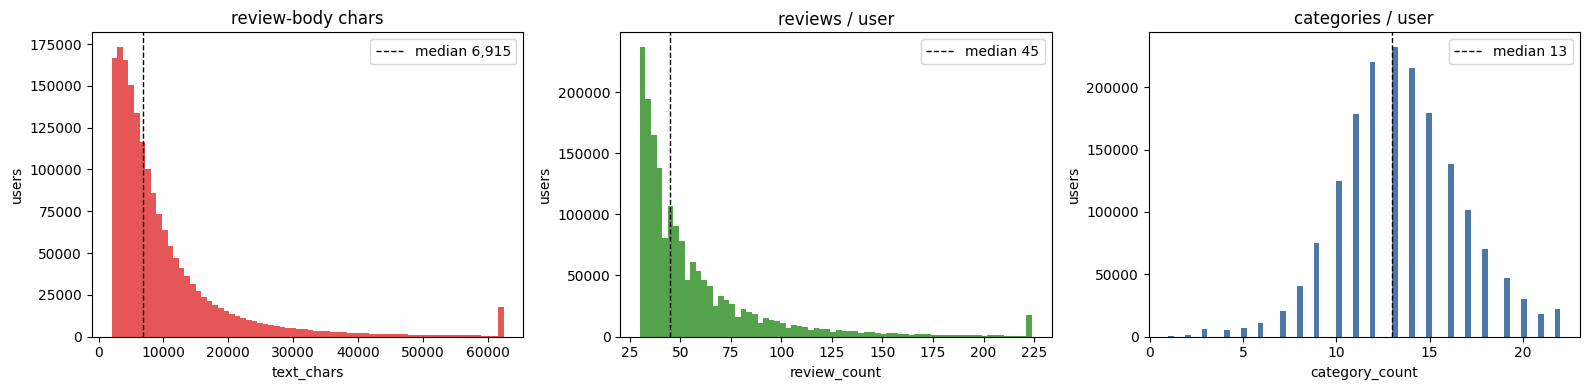

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (col, name, color) in zip(ax, [
    ("text_chars",   "review-body chars", "#E45756"),
    ("review_count", "reviews / user",    "#54A24B"),
    ("category_count","categories / user","#4C78A8"),
]):
    arr = users[col].values
    a.hist(np.clip(arr, 0, np.percentile(arr, 99)), bins=70, color=color)
    a.axvline(np.median(arr), color="k", ls="--", lw=1,
              label=f"median {int(np.median(arr)):,}")
    a.set(title=name, xlabel=col, ylabel="users")
    a.legend()
plt.tight_layout()
plt.show()

## 3. Assemble real `profile_text` + validate Qwen tokens

Pull one full user-bucket (all category files), concatenate each user's reviews
in chronological order, and tokenize with the Qwen tokenizer. This gives:
- the **real** token distribution of assembled profiles, and
- a **chars → tokens** factor we use to convert the cheap population `text_chars`
  into an estimated token budget.

`assemble_profile` is the canonical format the extraction script should reuse.

In [14]:
REVIEW_TMPL = ("[{date}] {category} | {parent_asin} | rating={rating:.0f}/5 | "
               "verified={verified}\nTitle: {title}\n{text}")

def assemble_profile(g: pd.DataFrame) -> str:
    """Concatenate one user's reviews (chronological) into a profile_text."""
    g = g.sort_values("timestamp")
    parts = [REVIEW_TMPL.format(
                date=r.date, category=r.category, parent_asin=r.parent_asin,
                rating=float(r.rating), verified=bool(r.verified_purchase),
                title=(r.title or ""), text=(r.text or ""))
             for r in g.itertuples()]
    header = (f"Amazon reviewer profile — {len(g)} reviews across "
              f"{g.category.nunique()} categories.\n\n")
    return header + "\n\n".join(parts)

def load_bucket_reviews(b: str) -> pd.DataFrame:
    """All reviews in one user_bucket (across every category file)."""
    files = [f for f in api.list_repo_files(REPO_ID, repo_type="dataset")
             if f.startswith(f"{UBUK}/bucket={b}/") and f.endswith(".parquet")]
    return pd.concat([pd.read_parquet(dl(f)) for f in files], ignore_index=True)

In [6]:
from transformers import AutoTokenizer
tk = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=f"{CACHE}/hub")

SAMPLE_BUCKET = "00"
N_USERS = 500
rev = load_bucket_reviews(SAMPLE_BUCKET)
print(f"bucket={SAMPLE_BUCKET}: {len(rev):,} reviews, {rev.user_id.nunique():,} users")

uids = rev.user_id.drop_duplicates().sample(min(N_USERS, rev.user_id.nunique()),
                                            random_state=0)
sub = rev[rev.user_id.isin(set(uids))]
prof = sub.groupby("user_id", sort=False).apply(assemble_profile)
texts = prof.tolist()

chars = np.array([len(t) for t in texts])
toks = np.array([len(x) for x in tk(texts, add_special_tokens=False)["input_ids"]])
CHARS_PER_TOKEN = chars.sum() / toks.sum()

stats(chars, "assembled chars")
stats(toks,  "assembled tokens")
print(f"\nchars/token ratio    : {CHARS_PER_TOKEN:.2f}")

# map population text_chars -> assembled tokens using this sample
s_stats = users.set_index("user_id").loc[prof.index, ["text_chars", "text_reviews"]]
ratio = toks / s_stats["text_chars"].values          # tokens per body-char
TOK_PER_BODYCHAR = float(np.median(ratio))
print(f"tokens per body-char : {TOK_PER_BODYCHAR:.4f}  "
      f"(assembled tokens / eligible_users.text_chars)")

bucket=00: 405,005 reviews, 6,920 users


/tmp/ipykernel_493053/4189606737.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prof = sub.groupby("user_id", sort=False).apply(assemble_profile)


assembled chars mean=    17532  min= 5,114  p5=  6,485  p50= 12,540  p90= 33,328  p99= 88,263  max=   170,689
assembled tokens mean=     5312  min= 1,752  p5=  2,178  p50=  3,919  p90=  9,198  p99= 24,183  max=    47,085

chars/token ratio    : 3.30
tokens per body-char : 0.5352  (assembled tokens / eligible_users.text_chars)


In [7]:
print("--- example assembled profile_text (head) ---\n")
print(texts[0][:800])

--- example assembled profile_text (head) ---

Amazon reviewer profile — 73 reviews across 19 categories.

[2020-08-15] Pet_Supplies | B09G5R61TJ | rating=5/5 | verified=True
Title: Treats!
My babies absolutely love these!

[2020-08-15] Pet_Supplies | B072BYV875 | rating=5/5 | verified=True
Title: Treats!
My babies love all the flavors of these treats!

[2020-08-15] Movies_and_TV | B06XCGMRDK | rating=5/5 | verified=True
Title: Wonderful movie!
This is a great movie!

[2020-08-15] Pet_Supplies | B0BTJ296MW | rating=4/5 | verified=True
Title: Treats
I bought these for someone else... My babies don't like these at all.

[2020-08-15] Office_Products | B000QYLCWK | rating=5/5 | verified=True
Title: Gift
This was a gift for someone else... I love gifting people!

[2020-08-15] Books | 0736424229 | rating=5/5 | verified=True
Title: Gift
This 


## 4. Length filter → target ~100K users

Convert the population `text_chars` to an **estimated assembled-token** budget
(`text_chars * TOK_PER_BODYCHAR`) and apply two cuts:

- **too long:** would not fit the Qwen 35B context. The extraction prompt reuses
  the profile in every dimension-chunk; with `max_model_len=32768`, ~5.5k tokens
  of instructions/dimension lines, and 8k reserved for output, the profile budget
  is roughly **19k tokens**. We keep a safety margin → `MAX_TOKENS`.
- **too short:** weak signal. All eligible users already have ≥30 reviews and
  ≥2000 body chars; `MIN_TOKENS` trims the very shortest.

Tune the three knobs and re-run.

In [8]:
MAX_TOKENS = 16000     # drop users whose assembled profile is too long to fit ctx
MIN_TOKENS = 700       # drop users too short to carry signal
TARGET     = 100_000   # desired final count
SEED       = 20260705

users = users.copy()
users["est_tokens"] = (users["text_chars"] * TOK_PER_BODYCHAR).round().astype(int)

fits = (users["est_tokens"] >= MIN_TOKENS) & (users["est_tokens"] <= MAX_TOKENS)
n_short = int((users["est_tokens"] < MIN_TOKENS).sum())
n_long  = int((users["est_tokens"] > MAX_TOKENS).sum())
kept = users[fits]

print(f"population         : {len(users):,}")
print(f"too short (<{MIN_TOKENS}) : {n_short:,} ({100*n_short/len(users):.2f}%)")
print(f"too long  (>{MAX_TOKENS}): {n_long:,} ({100*n_long/len(users):.2f}%)")
print(f"within window      : {len(kept):,} ({100*len(kept)/len(users):.1f}%)")
print(f"target             : {TARGET:,}  -> "
      f"{'random-sample down' if len(kept)>TARGET else 'KEEP ALL (below target!)'}")

stats(kept["est_tokens"].values, "kept est_tokens")

population         : 1,744,018
too short (<700) : 0 (0.00%)
too long  (>16000): 84,276 (4.83%)
within window      : 1,659,742 (95.2%)
target             : 100,000  -> random-sample down
kept est_tokens mean=     4486  min= 1,070  p5=  1,307  p50=  3,533  p90=  8,983  p99= 14,618  max=    16,000


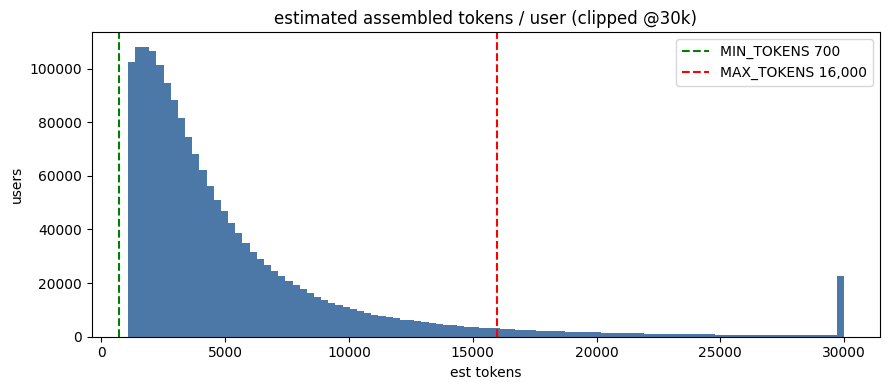

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
arr = np.clip(users["est_tokens"].values, 0, 30000)
ax.hist(arr, bins=100, color="#4C78A8")
ax.axvline(MIN_TOKENS, color="green", ls="--", label=f"MIN_TOKENS {MIN_TOKENS:,}")
ax.axvline(MAX_TOKENS, color="red", ls="--", label=f"MAX_TOKENS {MAX_TOKENS:,}")
ax.set(title="estimated assembled tokens / user (clipped @30k)",
       xlabel="est tokens", ylabel="users")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Select ~100K and save the selection index

Random-sample `TARGET` users from the in-window set (reproducible via `SEED`) and
save `user_id, user_bucket, review_count, text_chars, est_tokens`. The extraction
job reads this index, assembles each user's `profile_text` from `user_buckets`
(via `assemble_profile`), and runs the same Qwen dimension extraction as wiki.

In [10]:
n_take = min(TARGET, len(kept))
selection = (kept.sample(n=n_take, random_state=SEED)
                 .sort_values(["user_bucket", "user_id"])
                 .reset_index(drop=True))

OUT = Path("/n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/"
           "persona/human_extraction/data/amazon")
OUT.mkdir(parents=True, exist_ok=True)
sel_path = OUT / f"selected_users_{n_take//1000}k.parquet"
selection[["user_id", "user_bucket", "review_count", "text_chars",
           "est_tokens"]].to_parquet(sel_path)

print(f"selected {len(selection):,} users -> {sel_path}")
print("per-bucket counts (head):")
print(selection["user_bucket"].value_counts().sort_index().head())
selection.head()

selected 100,000 users -> /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/human_extraction/data/amazon/selected_users_100k.parquet
per-bucket counts (head):
user_bucket
00    385
01    411
02    396
03    376
04    384
Name: count, dtype: int64


,user_id,user_bucket,review_count,text_chars,text_reviews,category_count,verified_share,average_rating,est_tokens
0,AE2PVGJP2A7PXXOGR6ZOTDSMX4CA,00,71,7253,71,18,0.971831,4.661972,3881
1,AE4MSVM3PMIOAHLDAZQBZEBV42QQ,00,58,12046,58,15,0.948276,4.396552,6446
2,AE4ZJ52HPRP4KZHEP57ZI5TRZZBA,00,33,10358,33,14,0.939394,3.818182,5543
3,AE563AU3SUO2DOP4KMAKUOQWY5NQ,00,89,24899,89,16,1.000000,4.471910,13325
4,AE5C4ZXD7GZYMKDIGCRQA4HAJIWQ,00,37,17565,37,15,0.945946,4.081081,9400


## 6. Notes

- **Unit = user.** One persona per Amazon reviewer, `profile_text` = all their
  reviews (chronological) via `assemble_profile` (section 3). Reuse that exact
  format in the extraction script so token budgets match.
- **Length source.** `eligible_users.text_chars` is review-body chars only;
  multiply by `TOK_PER_BODYCHAR` (~measured in section 3) to estimate assembled
  tokens. Amazon text tokenizes denser than wiki (chars/token ≈ 3.3 vs ~4).
- **Filter.** `MIN_TOKENS`/`MAX_TOKENS` drop too-short / too-long users; the vast
  majority fit — the long tail (a few users reach millions of chars) is what the
  MAX cut removes so every kept profile fits the 32k context in one piece.
- **Selection** is reproducible (`SEED`) and saved to
  `data/amazon/selected_users_*.parquet` for the sharded extraction step.